<a href="https://colab.research.google.com/github/sonjoy1s/LungCancer/blob/main/LungCancerForPaper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [125]:
import os
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.datasets import ImageFolder
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [126]:
base_path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", base_path)

Using Colab cache for faster access to the 'lung-cancer-histopathological-images' dataset.
Path to dataset files: /kaggle/input/lung-cancer-histopathological-images


In [127]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [128]:
categories = ['adenocarcinoma','benign','squamous_cell_carcinoma']

In [129]:
images = []
labels = []

# Iterate through each category to build paths
for cls in categories:
    cls_path = os.path.join(base_path, cls)
    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        images.append(os.path.join(cls_path, img_name))
        labels.append(cls)

df = pd.DataFrame({
    'image': images,
    'label': labels
})

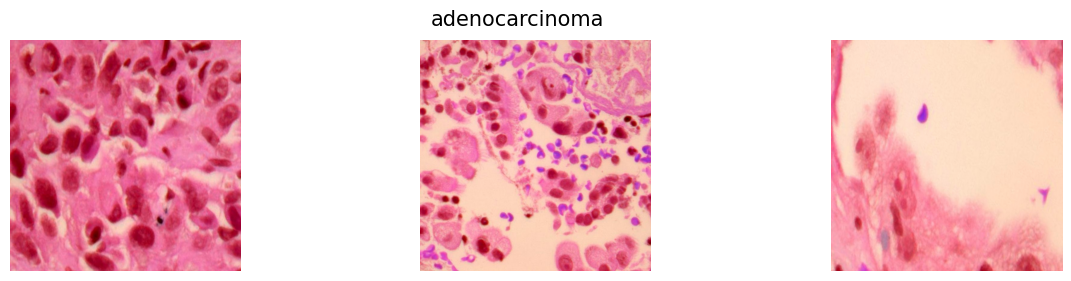

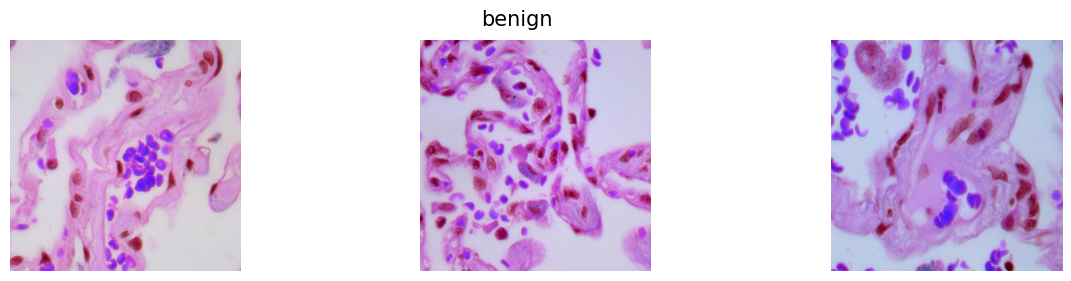

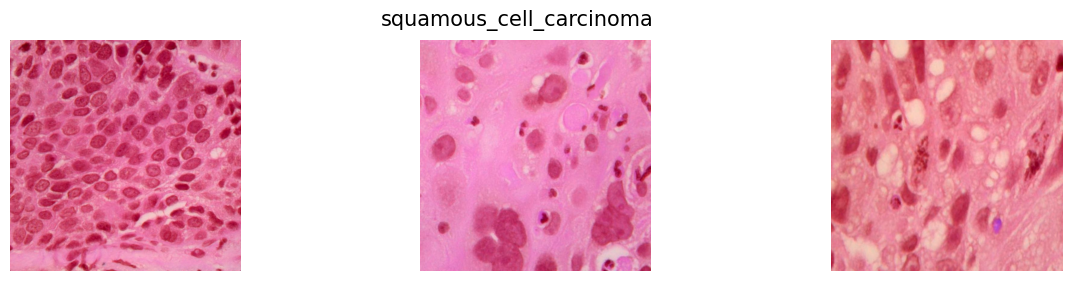

In [130]:
import cv2
import matplotlib.pyplot as plt
for cat in categories:
    # Construct the full path for the current category
    category_path = os.path.join(base_path, cat)
    images = os.listdir(category_path)
    # Initialize a subplot with 1 row and 3 columns
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    fig.suptitle(f'{cat}', fontsize=15)

    for i in range(3):
        # Randomly select an image
        img_name = images[np.random.randint(0, len(images))]
        img_path = os.path.join(category_path, img_name)
        img_array = cv2.imread(img_path)

        # Display the image
        ax[i].imshow(img_array)
        ax[i].axis('off')

In [131]:
df['label_id'], uniques = pd.factorize(df['label'])
#df['image_path'],uniques = pd.factorize(df['image'])
print("Class Names:", uniques.tolist())

Class Names: ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']


In [133]:
X_train,X_test= train_test_split(df['label_id'],test_size=0.2,random_state=42)

In [134]:
X_train

,label_id
9839,1
9680,1
7093,1
11293,2
820,0
...,...
5191,1
13418,2
5390,1
860,0


In [136]:
transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5)*3,std=(0.5)*3)
    ]
)

In [137]:
from genericpath import isfile

class MyCustomeData(Dataset):
    def __init__(self, dataframe, transform=None):
        self.paths = dataframe['image'].values
        self.labels = dataframe['label_id'].values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img_path = self.paths[idx]
        img = Image.open(img_path).convert("RGB")

        label = int(self.labels[idx])

        if self.transform:
            img = self.transform(img)

        return img, label

In [138]:
train_dataset_full = MyCustomeData(df.loc[X_train.index], transform)
test_dataset_full = MyCustomeData(df.loc[X_test.index], transform)
num_classes = len(uniques)

print("Number of classes:", num_classes)
print("Full train size:", len(train_dataset_full))
print("Full test size:", len(test_dataset_full))

Number of classes: 3
Full train size: 12000
Full test size: 3000


In [139]:
train_dataset = Subset(train_dataset_full, list(range (8000, len(train_dataset_full))))
test_dataset = Subset(test_dataset_full, list(range(1000, len(test_dataset_full))))

In [140]:
print(len(train_dataset))
print(len(test_dataset))

4000
2000


In [141]:
pin = True if device.type == 'cuda' else False
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=pin)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=pin)

In [142]:
class MyCNNs(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [143]:
model = MyCNNs(num_classes=num_classes).to(device)

In [144]:
learning_rate = 0.001
epochs = 25
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [145]:

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/25, Loss: 0.8622
Epoch 2/25, Loss: 0.6401
Epoch 3/25, Loss: 0.6033
Epoch 4/25, Loss: 0.5409
Epoch 5/25, Loss: 0.5165
Epoch 6/25, Loss: 0.4968
Epoch 7/25, Loss: 0.4916
Epoch 8/25, Loss: 0.4652
Epoch 9/25, Loss: 0.4442
Epoch 10/25, Loss: 0.4490
Epoch 11/25, Loss: 0.4288
Epoch 12/25, Loss: 0.4228
Epoch 13/25, Loss: 0.4117
Epoch 14/25, Loss: 0.4072
Epoch 15/25, Loss: 0.3985
Epoch 16/25, Loss: 0.3947
Epoch 17/25, Loss: 0.3839
Epoch 18/25, Loss: 0.3756
Epoch 19/25, Loss: 0.3753
Epoch 20/25, Loss: 0.3728
Epoch 21/25, Loss: 0.3713
Epoch 22/25, Loss: 0.3733
Epoch 23/25, Loss: 0.3688
Epoch 24/25, Loss: 0.3621
Epoch 25/25, Loss: 0.3672


In [147]:
def evaluate(loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
    return correct / total

In [148]:
test_acc = evaluate(test_loader)
print("Test Accuracy:", test_acc)
train_acc = evaluate(train_loader)
print("Train Accuracy:", train_acc)


Test Accuracy: 0.959
Train Accuracy: 0.99975
